#### Import Joel's drug targets code

In [ ]:
import requests
import json
from j_drug_targets import get_msi_data, extract_msi_records, get_disease_subtypes

In [ ]:
efo_id = "EFO_0002939"  # Medulloblastoma

In [ ]:
final_results = {}

# 1. Get subtypes
subtypes = get_disease_subtypes(efo_id)
    
    # We include the parent and its subtypes in the analysis
all_related_ids = [efo_id] + [s['id'] for s in subtypes] # Limit to 5 subtypes for brevity
    
for d_id in all_related_ids:
    raw_data = get_msi_data(d_id)
    msi_record = extract_msi_records(raw_data)
        
    if msi_record:
        final_results[msi_record["umls_id"]] = {
            "name": msi_record["disease_name"],
            "efo_id": d_id,
            "drug_targets": msi_record["drugs"]
        }



In [5]:
# Extract all unique gene symbol targets across all diseases and drugs
drug_target_genes = set()

for umls_id, disease_data in final_results.items():
    for drug_id, drug_data in disease_data["drug_targets"].items():
        drug_target_genes.update(drug_data.get("target_gene_symbols", []))

drug_target_genes = list(drug_target_genes)
print(drug_target_genes)


['TOP2A', 'RBX1', 'KDR', 'SMO', 'CRBN', 'GSR', 'CCND1', 'TOP2B', 'CSNK2A1', 'DDB1', 'CDK4', 'CUL4A', 'DNMT1', 'DNMT3A', 'FNTB', 'CDK6', 'FNTA']


### Import seeds from DisGeNET query file

In [6]:
import pandas as pd

In [9]:
disgenet_res = pd.read_csv('disease_seeds/medulloblastoma_disgenet.tsv', sep='\t')
disgenet_res.head()


,ei,N CTs,N variants g,N PMIDs Chemicals,Gene,pLI,Gene Full Name,First Ref.,Last Ref.,N Chemicals,N PMIDs,score,N diseases g,My Score,DSI g,DPI g,N variants gda
0,1.000000,1,10500,0,BRCA2,5.769100e-44,BRCA2 DNA repair associated,1995.0,2022.0,0,39,1.00,94,NaN,0.39,0.88,297
1,0.924528,0,740,0,SUFU,1.000000e+00,SUFU negative regulator of hedgehog signaling,1996.0,2023.0,0,33,1.00,27,NaN,0.49,0.83,577
2,0.920635,1,127,0,CTNNB1,1.000000e+00,catenin beta 1,1999.0,2002.0,0,3,1.00,99,NaN,0.31,0.88,7
3,0.933333,1,2503,0,PTCH1,1.000000e+00,patched 1,2008.0,2009.0,0,3,1.00,78,NaN,0.41,0.88,1
4,0.888889,1,619,0,ELP1,1.115500e-23,elongator acetyltransferase complex subunit 1,2001.0,2020.0,0,6,0.95,12,NaN,0.55,0.83,223


In [10]:
input_genes = list(disgenet_res['Gene'])
input_genes[:10]

['BRCA2',
 'SUFU',
 'CTNNB1',
 'PTCH1',
 'ELP1',
 'APC',
 'MYC',
 'GPR161',
 'PTCH2',
 'SMO']

In [11]:
if len(input_genes) > 150:
    input_genes = input_genes[:150]

len(input_genes)

61

### Import hidef output

##### Import HiDeF persistent cluster assignments

In [12]:
k_persistency = 10

In [13]:

# Import nodes file from HiDeF output (test_run_1_.nodes) into a dictionary with cluster id as key and list of genes as value
nodes_df = pd.read_csv(f'output_examples/test_run_k{k_persistency}_.nodes', sep='\t', header=None)

# Column 0: cluster name, column 1: size, column 2: space-separated genes
nodes_dict = {
    row[0]: row[2].split()
    for _, row in nodes_df.iterrows()
}


#### Import HiDeF Hierarchy Graph

In [14]:
hierarchy_graph = pd.read_csv(f'output_examples/test_run_k{k_persistency}_.edges', sep='\t', header=None)
hierarchy_graph.head()

,0,1,2
0,Cluster0-0,Cluster1-0,default
1,Cluster0-0,Cluster1-1,default
2,Cluster0-0,Cluster1-2,default
3,Cluster0-0,Cluster1-3,default
4,Cluster0-0,Cluster1-4,default


In [15]:
hierarchy_graph.shape

(1204, 3)

### Identify Persistent clusters with disease genes or drug targets

In [ ]:
# get all clusters that contain at least one of the input genes
clusters_with_input_genes = {
    cluster_id: genes
    for cluster_id, genes in nodes_dict.items()
    if any(gene in input_genes for gene in genes)
}

clusters_with_drug_targets = {
    cluster_id: genes
    for cluster_id, genes in nodes_dict.items()
    if any(gene in drug_target_genes for gene in genes)
}
comb_keys = set(clusters_with_input_genes.keys()) | set(clusters_with_drug_targets.keys())

In [18]:
# Get the subgraph of the hierarchy graph that only contains clusters with input genes or drug targets
reduced_hierarchy_graph = hierarchy_graph[
    (hierarchy_graph[0].isin(comb_keys)) &
    (hierarchy_graph[1].isin(comb_keys))
]

In [19]:
reduced_hierarchy_graph.head()

,0,1,2
0,Cluster0-0,Cluster1-0,default
1,Cluster0-0,Cluster1-1,default
2,Cluster0-0,Cluster1-2,default
4,Cluster0-0,Cluster1-4,default
20,Cluster0-0,Cluster1-20,default


In [20]:
reduced_hierarchy_graph.shape

(62, 3)

#### Fisher Test (Genes in HiDeF clusters)

In [25]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

# Background: all unique genes across all clusters
all_genes = set(gene for genes in nodes_dict.values() for gene in genes)
N = len(all_genes)  # total background genes

# ── Fisher test for disease seed genes ──────────────────────────────────────
disease_genes_in_background = set(input_genes) & all_genes
K_disease = len(disease_genes_in_background)

disease_results = []
for cluster_id, genes in clusters_with_input_genes.items():
    n = len(genes)
    k = sum(1 for gene in genes if gene in disease_genes_in_background)
    p_value = hypergeom.sf(k - 1, N, K_disease, n)
    disease_results.append({
        'cluster': cluster_id,
        'cluster_size': n,
        'disease_genes_in_cluster': k,
        'total_background': N,
        'total_disease_genes': K_disease,
        'p_value': p_value
    })

results_df = pd.DataFrame(disease_results).sort_values('p_value')
_, results_df['p_adj'], _, _ = multipletests(results_df['p_value'], method='fdr_bh')
results_df['significant'] = results_df['p_adj'] < 0.05
#results_df = results_df[results_df['disease_genes_in_cluster'] > 1]

print(f"[Disease genes] Background: {N} genes, {K_disease} disease genes")
print(f"Total clusters tested: {len(results_df)}")
display(results_df.head(30))

# ── Fisher test for drug target genes ───────────────────────────────────────
drug_genes_in_background = set(drug_target_genes) & all_genes
K_drug = len(drug_genes_in_background)

drug_results = []
for cluster_id, genes in clusters_with_drug_targets.items():
    n = len(genes)
    k = sum(1 for gene in genes if gene in drug_genes_in_background)
    p_value = hypergeom.sf(k - 1, N, K_drug, n)
    drug_results.append({
        'cluster': cluster_id,
        'cluster_size': n,
        'drug_target_genes_in_cluster': k,
        'total_background': N,
        'total_drug_target_genes': K_drug,
        'p_value': p_value
    })

drug_results_df = pd.DataFrame(drug_results).sort_values('p_value')
_, drug_results_df['p_adj'], _, _ = multipletests(drug_results_df['p_value'], method='fdr_bh')
drug_results_df['significant'] = drug_results_df['p_adj'] < 0.05
#drug_results_df = drug_results_df[drug_results_df['drug_target_genes_in_cluster'] > 1]

print(f"\n[Drug target genes] Background: {N} genes, {K_drug} drug target genes")
print(f"Total clusters tested: {len(drug_results_df)}")
display(drug_results_df.head(30))


[Disease genes] Background: 17053 genes, 57 disease genes
Total clusters tested: 56


,cluster,cluster_size,disease_genes_in_cluster,total_background,total_disease_genes,p_value,p_adj,significant
1,Cluster1-0,10341,50,17053,57,0.000006,0.000363,True
54,Cluster3-258,4,2,17053,57,0.000066,0.001836,True
11,Cluster2-17,74,4,17053,57,0.000108,0.002024,True
6,Cluster2-5,182,5,17053,57,0.000350,0.004902,True
27,Cluster4-16,20,2,17053,57,0.002007,0.022473,True
9,Cluster2-9,110,3,17053,57,0.005934,0.043826,True
19,Cluster3-18,38,2,17053,57,0.007144,0.043826,True
17,Cluster3-15,46,2,17053,57,0.010339,0.043826,True
51,Cluster2-497,4,1,17053,57,0.013304,0.043826,True
48,Cluster2-450,4,1,17053,57,0.013304,0.043826,True



[Drug target genes] Background: 17053 genes, 16 drug target genes
Total clusters tested: 15


,cluster,cluster_size,drug_target_genes_in_cluster,total_background,total_drug_target_genes,p_value,p_adj,significant
9,Cluster3-8,71,4,17053,16,4.834290e-07,0.000007,True
6,Cluster2-8,124,4,17053,16,4.529971e-06,0.000025,True
14,Cluster2-557,4,2,17053,16,4.946646e-06,0.000025,True
11,Cluster2-182,10,2,17053,16,3.697818e-05,0.000127,True
8,Cluster2-17,74,3,17053,16,4.217994e-05,0.000127,True
13,Cluster3-258,4,1,17053,16,3.748056e-03,0.008130,True
1,Cluster1-0,10341,15,17053,16,3.794141e-03,0.008130,True
12,Cluster2-205,9,1,17053,16,8.414606e-03,0.015777,True
10,Cluster2-38,44,1,17053,16,4.051119e-02,0.067519,False
7,Cluster2-9,110,1,17053,16,9.840302e-02,0.147605,False


##### Plot Hierarchy (with significant Fisher test nodes)

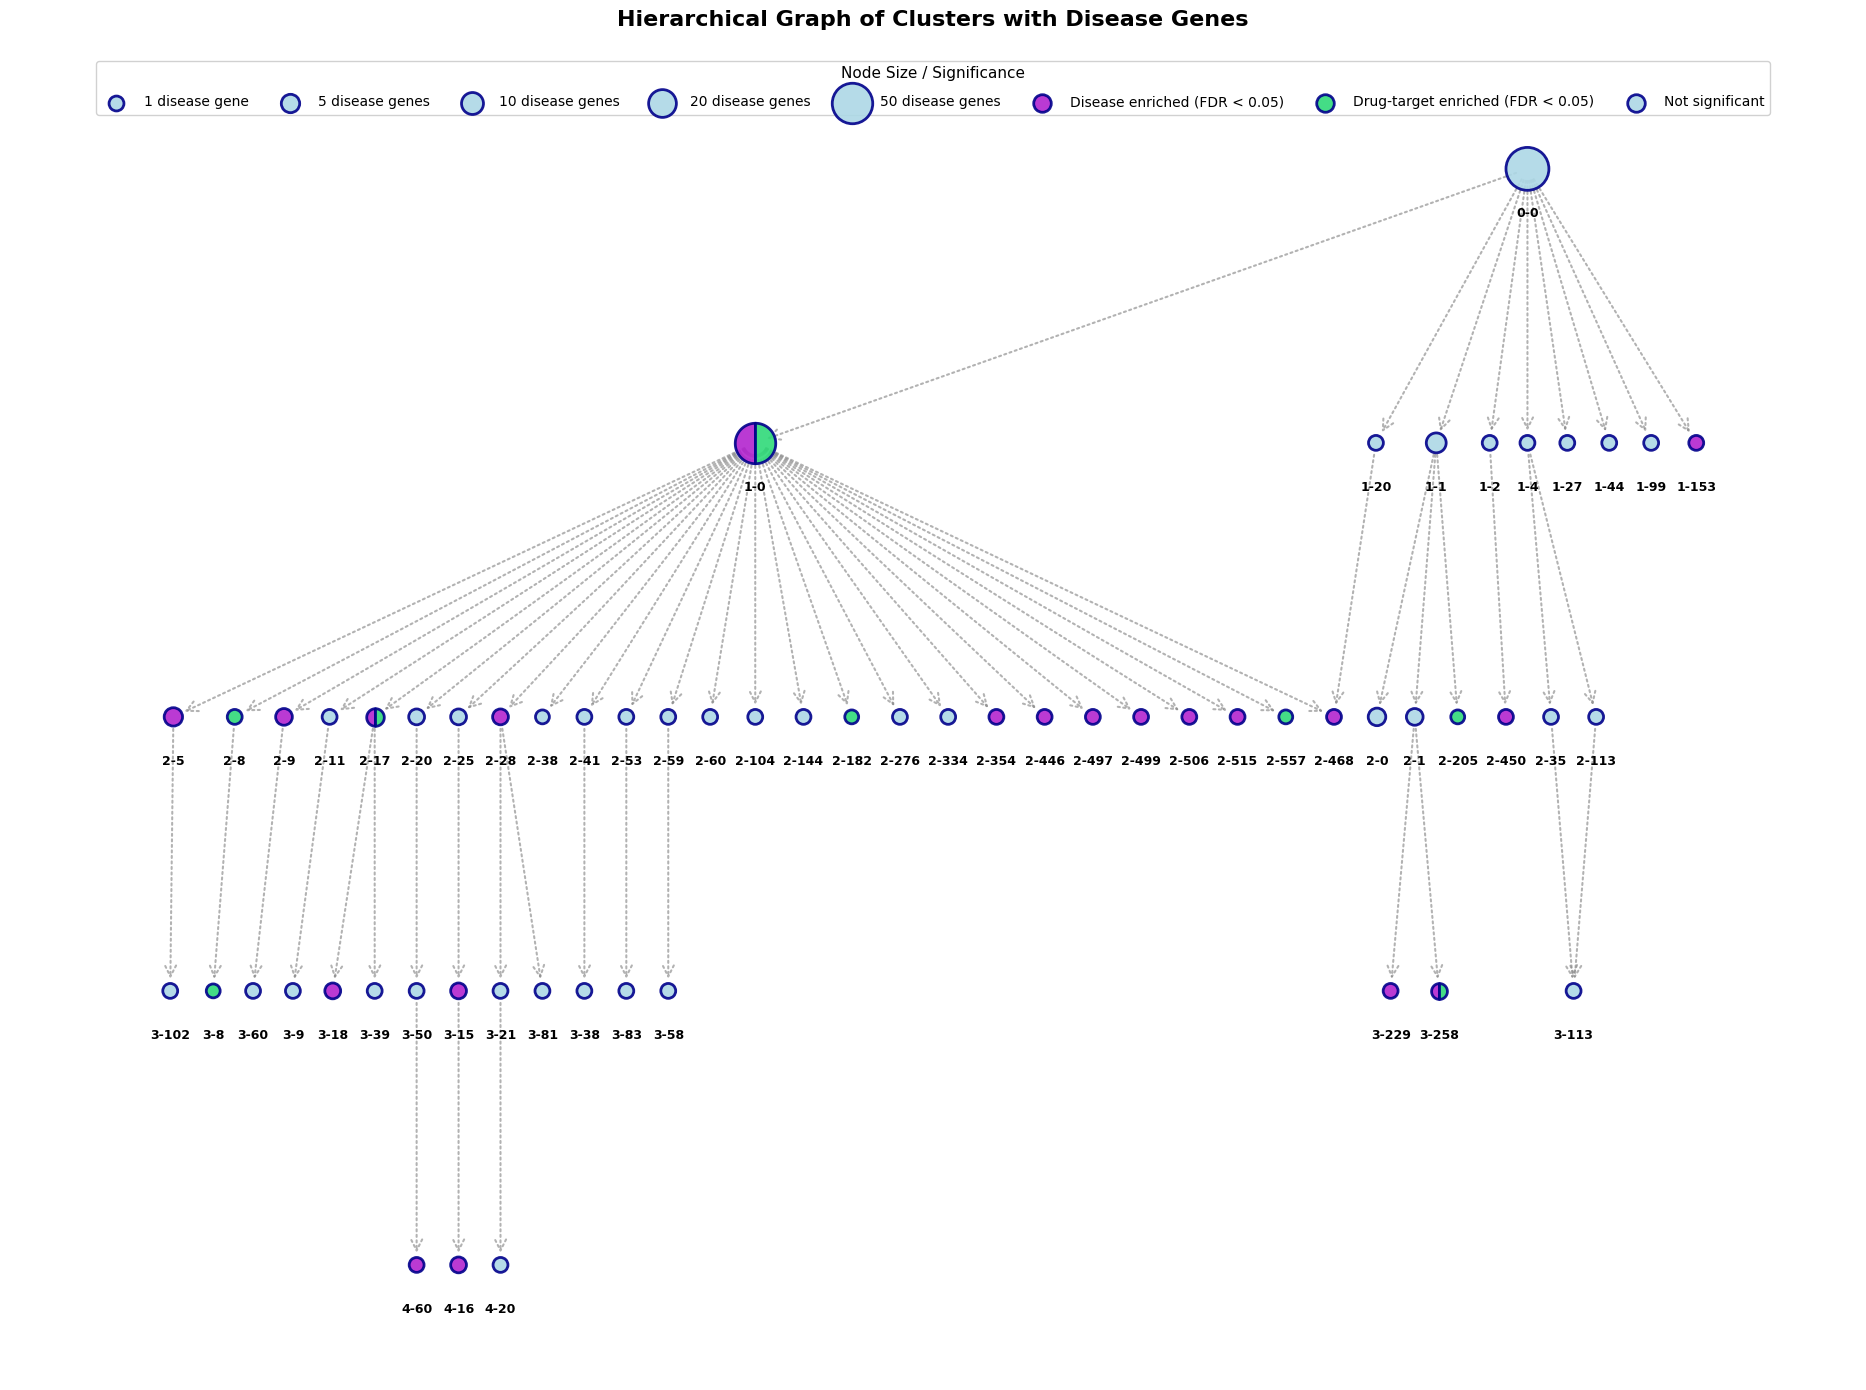

In [37]:

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import numpy as np
import pygraphviz

# ── Half-circle marker paths (for split "both significant" nodes) ──────────
theta_l = np.linspace(np.pi / 2, 3 * np.pi / 2, 100)
verts_left  = np.concatenate([[[0, 0]], np.c_[np.cos(theta_l), np.sin(theta_l)], [[0, 0]]])
codes_left  = [Path.MOVETO] + [Path.LINETO] * 100 + [Path.CLOSEPOLY]
left_half_marker = Path(verts_left, codes_left)

theta_r = np.linspace(-np.pi / 2, np.pi / 2, 100)
verts_right = np.concatenate([[[0, 0]], np.c_[np.cos(theta_r), np.sin(theta_r)], [[0, 0]]])
codes_right = [Path.MOVETO] + [Path.LINETO] * 100 + [Path.CLOSEPOLY]
right_half_marker = Path(verts_right, codes_right)

# ── Build directed graph ───────────────────────────────────────────────────
G = nx.from_pandas_edgelist(reduced_hierarchy_graph, source=0, target=1, create_using=nx.DiGraph())

# Build significance lookups
sig_lookup      = results_df.set_index('cluster')[['significant', 'p_adj']].to_dict('index')
drug_sig_lookup = drug_results_df.set_index('cluster')[['significant', 'p_adj']].to_dict('index')

# Node sizes based on number of disease genes per cluster
node_sizes_orig = {}
for node in G.nodes():
    if node in clusters_with_input_genes:
        cnt = sum(1 for g in clusters_with_input_genes[node] if g in input_genes)
        node_sizes_orig[node] = 100 + cnt * 15
    else:
        node_sizes_orig[node] = 100

# Relabel: strip 'Cluster' prefix
old_to_new          = {n: n.replace('Cluster', '') for n in G.nodes()}
sig_lookup_new      = {old_to_new[k]: v for k, v in sig_lookup.items()      if k in old_to_new}
drug_sig_lookup_new = {old_to_new[k]: v for k, v in drug_sig_lookup.items() if k in old_to_new}
node_sizes          = {old_to_new.get(k, k): v for k, v in node_sizes_orig.items()}

G = nx.relabel_nodes(G, lambda x: x.replace('Cluster', ''))

# ── Categorise nodes by enrichment status ─────────────────────────────────
disease_sig  = {n for n in G.nodes() if sig_lookup_new.get(n, {}).get('significant', False)}
drug_sig     = {n for n in G.nodes() if drug_sig_lookup_new.get(n, {}).get('significant', False)}
both_sig     = disease_sig & drug_sig
only_disease = disease_sig - drug_sig
only_drug    = drug_sig - disease_sig

COLOR_DRUG = "#2fda79"
COLOR_DISEASE    = "#b324cf"
COLOR_NONE    = 'lightblue'

def node_color(n):
    if n in only_disease: return COLOR_DISEASE
    if n in only_drug:    return COLOR_DRUG
    return COLOR_NONE

# ── Layout ─────────────────────────────────────────────────────────────────
pos = nx.nx_agraph.graphviz_layout(G, prog='dot')

label_offset = 10
label_pos    = {n: (x, y - label_offset) for n, (x, y) in pos.items()}

# ── Draw ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 14), facecolor='white')

# Edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                       arrowsize=20, arrowstyle='->', width=1.5,
                       alpha=0.6, style='dotted', ax=ax)

# Non-split nodes (only_disease / only_drug / not significant)
non_split = [n for n in G.nodes() if n not in both_sig]
nx.draw_networkx_nodes(G, pos, nodelist=non_split,
                       node_size=[node_sizes.get(n, 100) for n in non_split],
                       node_color=[node_color(n) for n in non_split],
                       edgecolors='darkblue', linewidths=2, alpha=0.9, ax=ax)

# Split nodes: left half = disease (green), right half = drug (purple)
for n in both_sig:
    x, y = pos[n]
    s = node_sizes.get(n, 100)
    ax.scatter(x, y, s=s, marker=left_half_marker,  c=COLOR_DISEASE,
               edgecolors='darkblue', linewidths=2, alpha=0.9, zorder=5)
    ax.scatter(x, y, s=s, marker=right_half_marker, c=COLOR_DRUG,
               edgecolors='darkblue', linewidths=2, alpha=0.9, zorder=5)

# Node labels only
nx.draw_networkx_labels(G, label_pos, font_size=9, font_weight='bold',
                        font_family='sans-serif', verticalalignment='top', ax=ax)

# ── Title ──────────────────────────────────────────────────────────────────
ax.set_title('Hierarchical Graph of Clusters with Disease Genes',
             fontsize=16, fontweight='bold', pad=20)

# ── Legend ─────────────────────────────────────────────────────────────────
legend_sizes = [1, 5, 10, 20, 50]
size_elements = [
    plt.scatter([], [], s=100 + s * 15, c=COLOR_NONE,
                edgecolors='darkblue', linewidths=2, alpha=0.9,
                label=f'{s} disease gene{"s" if s > 1 else ""}')
    for s in legend_sizes
]

color_elements = [
    plt.scatter([], [], s=160, c=COLOR_DISEASE, edgecolors='darkblue',
                linewidths=2, alpha=0.9, label='Disease enriched (FDR < 0.05)'),
    plt.scatter([], [], s=160, c=COLOR_DRUG,    edgecolors='darkblue',
                linewidths=2, alpha=0.9, label='Drug-target enriched (FDR < 0.05)'),
    plt.scatter([], [], s=160, c=COLOR_NONE,    edgecolors='darkblue',
                linewidths=2, alpha=0.9, label='Not significant'),
]

all_handles = size_elements + color_elements
ax.legend(handles=all_handles, loc='upper center', fontsize=10,
          title='Node Size / Significance', title_fontsize=11,
          framealpha=0.9, labelspacing=1, handletextpad=1,
          ncol=len(all_handles))

ax.axis('off')
plt.tight_layout()
plt.show()


### GSEA

In [34]:

import gseapy as gp
from multiprocessing import Pool

# Gene set databases to query
gene_sets = ['KEGG_2021_Human', 'Reactome_Pathways_2024','WikiPathways_2024_Human','GO_Molecular_Function_2025']

# Use clusters enriched in BOTH disease and drug targets; fall back to disease-only if none found
# both_sig contains relabelled node names (no 'Cluster' prefix), so re-add prefix to match cluster keys
both_sig_clusters = [f"Cluster{n}" for n in both_sig if f"Cluster{n}" in clusters_with_input_genes]

if both_sig_clusters:
    significant_clusters = both_sig_clusters
    print(f"Running GSEA on {len(significant_clusters)} cluster(s) enriched in BOTH disease and drug targets.")
else:
    significant_clusters = results_df[results_df['significant']]['cluster'].tolist()
    print(f"No clusters enriched in both — falling back to {len(significant_clusters)} disease-enriched cluster(s).")

gsea_results = {}

def run_enrichr(cluster_id):
    """Run Enrichr for a single cluster and return results"""
    genes = clusters_with_input_genes[cluster_id]
    
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=gene_sets,
        organism='human',
        outdir=None,
        background=all_genes,
        verbose=False
    )
    
    n_sig = (enr.results['Adjusted P-value'] < 0.05).sum()
    print(f"{cluster_id} ({len(genes)} genes): {n_sig} significant terms (FDR < 0.05)")
    
    return (cluster_id, enr.results)

# Run enrichment analysis in parallel
with Pool() as pool:
    results_list = pool.map(run_enrichr, significant_clusters)

# Convert list of tuples back to dictionary
for cluster_id, results in results_list:
    gsea_results[cluster_id] = results


Running GSEA on 3 cluster(s) enriched in BOTH disease and drug targets.


Cluster3-258 (4 genes): 60 significant terms (FDR < 0.05)Cluster2-17 (74 genes): 283 significant terms (FDR < 0.05)

Cluster2-17 (74 genes): 283 significant terms (FDR < 0.05)

Cluster1-0 (10341 genes): 1190 significant terms (FDR < 0.05)
Cluster1-0 (10341 genes): 1190 significant terms (FDR < 0.05)


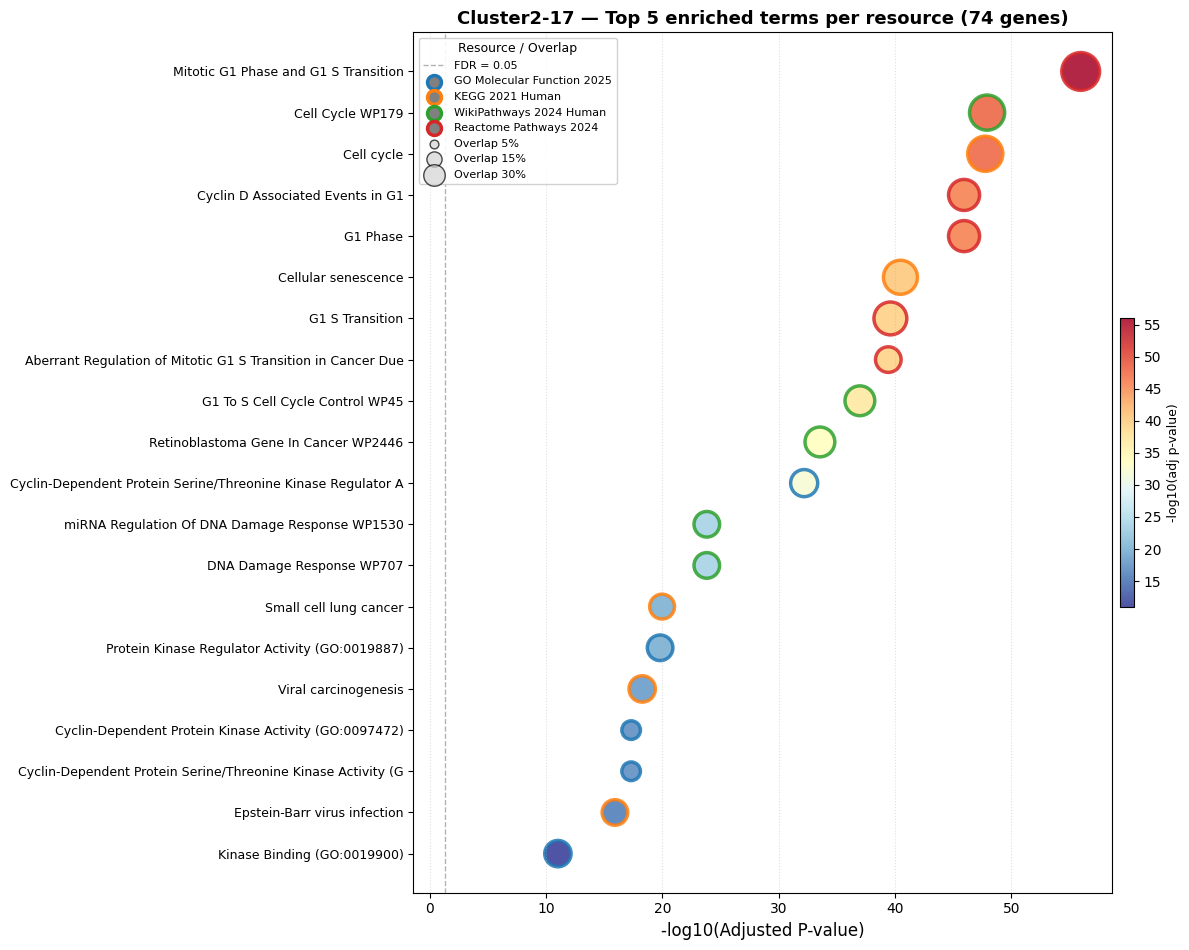

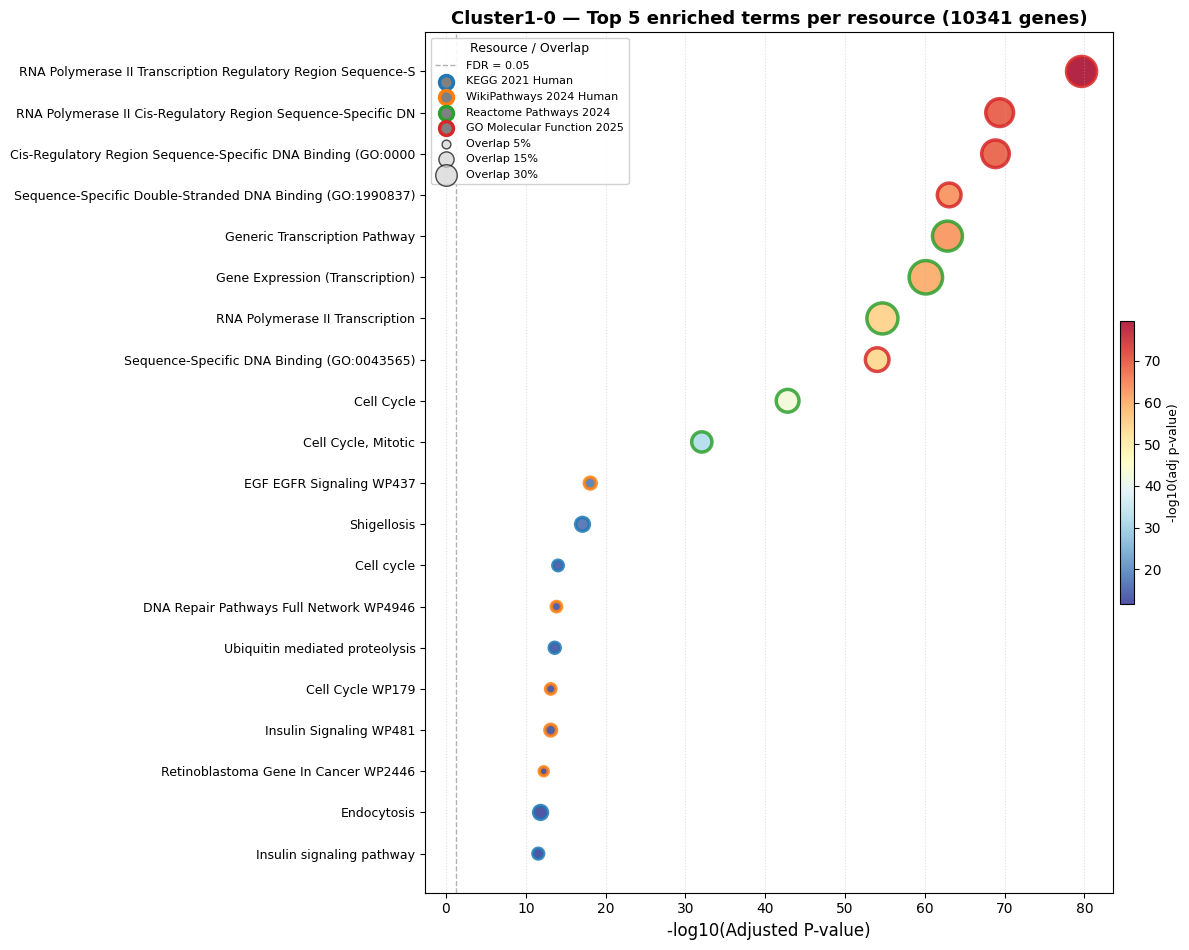

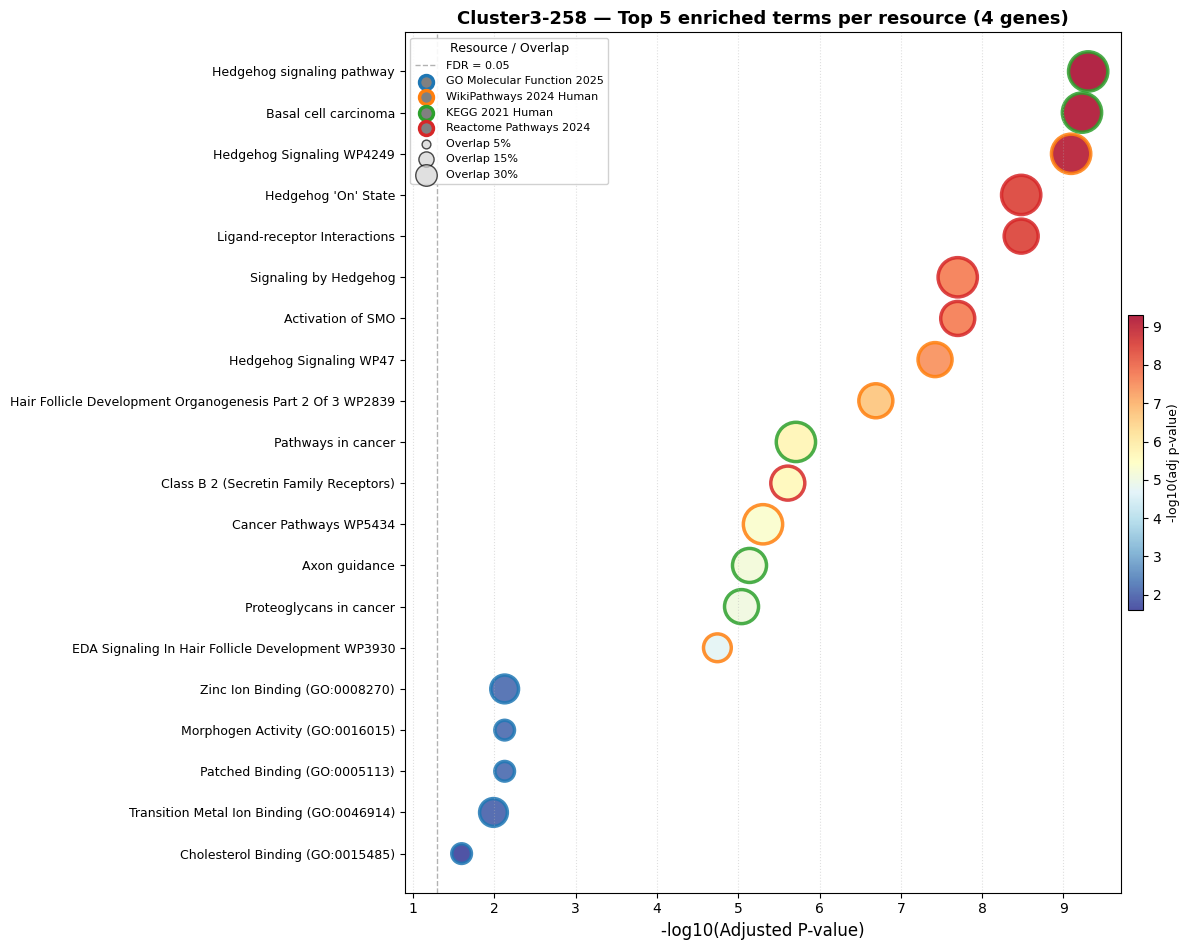

In [35]:
import numpy as np

# --- Parameters ---
top_n = 5        # top N terms per gene set resource per cluster
fdr_cutoff = 0.05

def parse_overlap(s):
    try:
        a, b = s.split('/')
        return int(a) / int(b)
    except:
        return 0.0

for cluster_id, df in gsea_results.items():
    df = df.copy()
    # Check for the overlap column name (could be 'Overlap' or 'Genes')
    if 'Overlap' in df.columns:
        df['overlap_ratio'] = df['Overlap'].apply(parse_overlap)
    elif 'Genes' in df.columns:
        # If there's no Overlap column, calculate from gene counts
        df['overlap_ratio'] = df['Genes'].str.split(';').apply(len) / df['Genes'].str.split(';').apply(len).max()
    else:
        df['overlap_ratio'] = 0.1  # default value
    df['-log10_padj'] = -np.log10(df['Adjusted P-value'].astype(float).clip(lower=1e-300))
    df['Term_short'] = df['Term'].str.slice(0, 60)

    # Select top N significant terms per gene set resource
    sig_df = df[df['Adjusted P-value'] < fdr_cutoff]
    top_df = (
        sig_df.sort_values('Adjusted P-value')
        .groupby('Gene_set')
        .head(top_n)
        .sort_values(['-log10_padj'], ascending=True)
    )

    if top_df.empty:
        print(f"{cluster_id}: no significant terms to plot.")
        continue

    # Color-code by gene set source
    sources = top_df['Gene_set'].unique()
    palette = plt.cm.tab10.colors
    source_colors = {src: palette[i % len(palette)] for i, src in enumerate(sources)}
    colors = [source_colors[s] for s in top_df['Gene_set']]

    fig, ax = plt.subplots(figsize=(12, max(5, len(top_df) * 0.38 + 2)), facecolor='white')

    scatter = ax.scatter(
        top_df['-log10_padj'],
        top_df['Term_short'],
        s=top_df['overlap_ratio'] * 800,
        c=top_df['-log10_padj'],
        cmap='RdYlBu_r',
        alpha=0.85,
        edgecolors=colors,
        linewidths=2.5
    )

    ax.axvline(x=-np.log10(fdr_cutoff), color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'FDR = {fdr_cutoff}')
    ax.set_xlabel('-log10(Adjusted P-value)', fontsize=12)
    ax.set_title(f'{cluster_id} — Top {top_n} enriched terms per resource ({len(clusters_with_input_genes[cluster_id])} genes)', fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle=':', alpha=0.4)

    # Colorbar for significance
    cbar = plt.colorbar(scatter, ax=ax, pad=0.01, fraction=0.02)
    cbar.set_label('-log10(adj p-value)', fontsize=9)

    # Gene set source legend (edge color)
    for src, col in source_colors.items():
        ax.scatter([], [], s=100, facecolors='gray', edgecolors=col, linewidths=2.5, label=src.replace('_', ' '))

    # Overlap size legend
    for ratio, label in [(0.05, '5%'), (0.15, '15%'), (0.30, '30%')]:
        ax.scatter([], [], s=ratio * 800, c='lightgray', edgecolors='black', linewidths=1, alpha=0.7, label=f'Overlap {label}')

    ax.legend(fontsize=8, loc='upper left', framealpha=0.9, title='Resource / Overlap', title_fontsize=9)

    plt.tight_layout()
    plt.show()
